# Full-trace three-class classification (`dataNEW`)
Predict **neutral**, **emotional**, or **joy** from one feature vector per whole trace.

1. Validate the individual whole-trace CSVs against `all_whole.csv`.
2. Reserve about 25% of nodes for a final test; keep node groups disjoint everywhere.
3. Quickly compare six classifier families plus a dummy baseline using training-only cross-validation.
4. Select the family with the highest mean CV balanced accuracy, then run a larger `GridSearchCV` on that family.
5. Evaluate once on held-out nodes, with per-class metrics, a confusion matrix, and individual predictions.

All imputation, constant-feature removal, and scaling are fitted inside each training fold. Run labels, node IDs, condition, duration, and other metadata are excluded from predictors. The only predictors are the original four throttle features from `fulltrace_analysis_NEJ.ipynb`:

- `core_power.throttle__mean_rate`
- `core_power.throttle__variance`
- `core_power.throttle__spectral_entropy`
- `core_power.throttle__slope`

Instruction counters, cycle counters, TLB counters, and the other throttle features are excluded.

**Interpretation:** only 67 traces are currently available. Node IDs are inferred from the numeric run-label prefix. Joy was collected in a different batch from emotional/neutral, so good prediction could reflect batch or workload differences. Node grouping reduces repeated-node leakage but cannot remove batch confounding or establish a causal condition effect. CV scores used for model selection are optimistic; the untouched test set is the final evaluation.

Use the project's `.mccvenv` kernel. Dependencies: numpy, pandas, matplotlib, scikit-learn, joblib, and Jupyter. Run all cells in order.

**Evaluation history:** this reanalysis keeps the previous node split for comparability. Its test set has already been inspected during the earlier analysis and feature audit, so the result is exploratory rather than a fresh independent confirmation. Model selection and tuning still use training folds only.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, GridSearchCV, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'dataNEW').is_dir())
DATA_DIR = ROOT / 'dataNEW'
OUTPUT_DIR = ROOT / 'output' / 'fulltrace_classification_four_throttle'
SEED = 42
N_JOBS = 1  # Small data: avoids process startup overhead; increase if desired.
FEATURE_SET = 'original_four_throttle'
FEATURES = [
    'core_power.throttle__mean_rate',
    'core_power.throttle__variance',
    'core_power.throttle__spectral_entropy',
    'core_power.throttle__slope',
]
CLASSES = ['neutral', 'emotional', 'joy']
print('Python:', platform.python_version(), '| scikit-learn:', sklearn.__version__)
print('Input:', DATA_DIR)

Python: 3.12.12 | scikit-learn: 1.8.0
Input: /Users/rsalvi/Desktop/mccviahat/dataNEW


## Load and audit
Read only top-level individual `*_whole.csv` files, so neither the combined file nor `dataNEW/70b` is counted again. Fail clearly on duplicates, inconsistent aggregate data, or unexpected labels.

In [2]:
paths = sorted(p for p in DATA_DIR.glob('*_whole.csv') if p.name != 'all_whole.csv')
if not paths:
    raise ValueError(f'No individual whole-trace CSVs in {DATA_DIR}')
frames = [pd.read_csv(p) for p in paths]
if any(len(frame) != 1 for frame in frames):
    raise ValueError('Each individual CSV must contain exactly one trace.')
df = pd.concat(frames, ignore_index=True).sort_values('run_label').reset_index(drop=True)
if df.run_label.isna().any() or df.run_label.duplicated().any():
    raise ValueError('Missing or duplicate run labels.')
if set(df.condition) != set(CLASSES) or not df['mode'].eq('whole_trace').all():
    raise ValueError('Expected whole traces with exactly neutral, emotional, and joy labels.')
combined_path = DATA_DIR / 'all_whole.csv'
if combined_path.exists():
    combined = pd.read_csv(combined_path).sort_values('run_label').reset_index(drop=True)
    pd.testing.assert_frame_equal(df, combined)
    print('Individual files match all_whole.csv.')
node = df.run_label.str.extract(r'^(\d+)_', expand=False)
if node.isna().any():
    raise ValueError('Cannot infer node group from a run label; specify groups explicitly.')
feature_columns = FEATURES.copy()
missing_features = [c for c in feature_columns if c not in df.columns]
if missing_features:
    raise ValueError(f'Missing required throttle features: {missing_features}')
assert len(feature_columns) == 4
print('Predictors:', feature_columns)
X = df[feature_columns].apply(pd.to_numeric, errors='raise').replace([np.inf, -np.inf], np.nan)
y = df.condition.copy()
groups = node.rename('node')
print(f'{len(df)} traces, {groups.nunique()} nodes, {len(feature_columns)} candidate features')
display(y.value_counts().reindex(CLASSES).rename('traces').to_frame())
display(pd.crosstab(groups, y).reindex(columns=CLASSES, fill_value=0))
display(X.isna().sum().loc[lambda s: s > 0].rename('missing_values').to_frame())

Individual files match all_whole.csv.
Predictors: ['core_power.throttle__mean_rate', 'core_power.throttle__variance', 'core_power.throttle__spectral_entropy', 'core_power.throttle__slope']
67 traces, 17 nodes, 4 candidate features


,traces
condition,
neutral,20
emotional,20
joy,27


condition,neutral,emotional,joy
node,,,
222,2,2,3
224,2,2,0
226,1,1,0
229,2,2,4
230,2,2,0
231,1,1,0
232,1,1,0
234,0,0,4
235,1,1,0


,missing_values


## Freeze the node-disjoint test set and CV folds
Use the first seeded group split for which both partitions and every CV fold contain all three classes. This feasibility check uses labels and groups only, never feature values or model scores. Three CV folds are used because joy occurs on relatively few nodes. The exact assignments are exported for reproducibility.

In [3]:
def has_all_classes(indices):
    return set(y.iloc[indices]) == set(CLASSES)

splitter = GroupShuffleSplit(n_splits=200, test_size=0.25, random_state=SEED)
for train_idx, test_idx in splitter.split(X, y, groups):
    if not (has_all_classes(train_idx) and has_all_classes(test_idx)):
        continue
    cv = list(StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED).split(
        X.iloc[train_idx], y.iloc[train_idx], groups.iloc[train_idx]))
    if all(has_all_classes(train_idx[a]) and has_all_classes(train_idx[b]) for a, b in cv):
        break
else:
    raise ValueError('No feasible grouped split found; inspect class-by-node coverage.')
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]
assert set(g_train).isdisjoint(g_test)
for a, b in cv:
    assert set(g_train.iloc[a]).isdisjoint(g_train.iloc[b])
    assert set(g_train.iloc[a]).isdisjoint(g_test)
assignments = df[['run_label', 'condition']].copy()
assignments['node'] = groups
assignments['partition'] = 'test'
assignments.loc[train_idx, 'partition'] = 'train'
assignments['validation_fold'] = pd.Series(pd.NA, index=df.index, dtype='Int64')
for fold, (_, b) in enumerate(cv, start=1):
    assignments.loc[train_idx[b], 'validation_fold'] = fold
print(f'Training: {len(train_idx)} traces / {g_train.nunique()} nodes')
print(f'Test: {len(test_idx)} traces / {g_test.nunique()} nodes')
display(pd.crosstab(assignments.partition, assignments.condition).reindex(columns=CLASSES))
display(pd.crosstab(assignments.validation_fold, assignments.condition).reindex(columns=CLASSES))

Training: 46 traces / 12 nodes
Test: 21 traces / 5 nodes


condition,neutral,emotional,joy
partition,,,
test,7,7,7
train,13,13,20


condition,neutral,emotional,joy
validation_fold,,,
1,4,4,12
2,5,5,4
3,4,4,4


## Quick classifier sweep
Each family gets a small grid on identical folds. Rank by **balanced accuracy** (mean per-class recall; chance baseline is 1/3), with macro F1 as a tie-breaker. Ordinary accuracy is also recorded. The dummy baseline is reported but excluded from family selection. Empty features are imputed to zero and removed by the fold-local variance filter; scaling precedes variance filtering to accommodate the very different hardware units.

,classifier,cv_balanced_accuracy,cv_std,cv_macro_f1,cv_accuracy,parameters
0,knn,0.746296,0.104067,0.705499,0.718254,{'model__n_neighbors': 7}
1,extra_trees,0.712963,0.085867,0.686379,0.708730,{'model__max_depth': 3}
2,rbf_svm,0.709259,0.095832,0.670760,0.684921,"{'model__C': 10, 'model__gamma': 'scale'}"
3,random_forest,0.690741,0.160781,0.664406,0.696032,{'model__max_depth': 3}
4,logistic_regression,0.635185,0.083189,0.614109,0.640476,{'model__C': 1}
5,gaussian_nb,0.557407,0.148403,0.499194,0.516667,{'model__var_smoothing': 1e-09}
6,dummy,0.333333,0.000000,0.141975,0.273016,{}


Selected family: knn


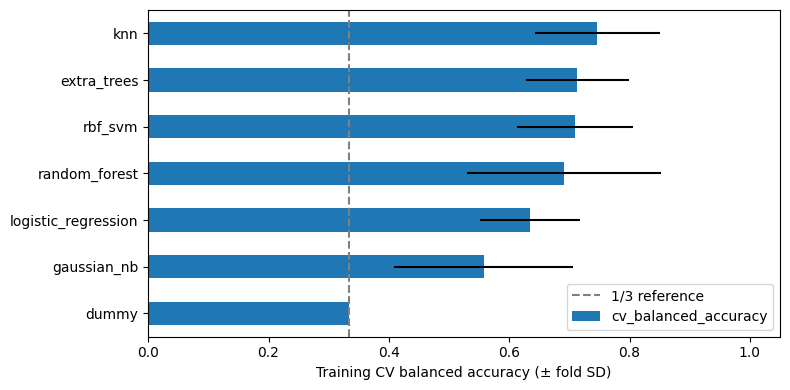

In [4]:
def pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
        ('scale', StandardScaler()),
        ('variance', VarianceThreshold()),
        ('model', model),
    ])

families = {
    'logistic_regression': (LogisticRegression(max_iter=10000, random_state=SEED), {'model__C': [0.1, 1, 10]}),
    'rbf_svm': (SVC(kernel='rbf'), {'model__C': [0.1, 1, 10], 'model__gamma': ['scale']}),
    'knn': (KNeighborsClassifier(), {'model__n_neighbors': [3, 5, 7]}),
    'random_forest': (RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=1), {'model__max_depth': [None, 3]}),
    'extra_trees': (ExtraTreesClassifier(n_estimators=150, random_state=SEED, n_jobs=1), {'model__max_depth': [None, 3]}),
    'gaussian_nb': (GaussianNB(), {'model__var_smoothing': [1e-9, 1e-3]}),
    'dummy': (DummyClassifier(strategy='most_frequent'), {}),
}
scoring = {'balanced_accuracy': 'balanced_accuracy', 'macro_f1': 'f1_macro', 'accuracy': 'accuracy'}
quick_searches, rows = {}, []
for name, (model, params) in families.items():
    search = GridSearchCV(pipeline(model), params, scoring=scoring, refit='balanced_accuracy',
                          cv=cv, n_jobs=N_JOBS, error_score='raise')
    search.fit(X_train, y_train)
    quick_searches[name] = search
    i = search.best_index_
    rows.append({'classifier': name, 'cv_balanced_accuracy': search.best_score_,
                 'cv_std': search.cv_results_['std_test_balanced_accuracy'][i],
                 'cv_macro_f1': search.cv_results_['mean_test_macro_f1'][i],
                 'cv_accuracy': search.cv_results_['mean_test_accuracy'][i],
                 'parameters': search.best_params_})
leaderboard = pd.DataFrame(rows).sort_values(
    ['cv_balanced_accuracy', 'cv_macro_f1', 'classifier'], ascending=[False, False, True]).reset_index(drop=True)
best_family = leaderboard.loc[leaderboard.classifier != 'dummy', 'classifier'].iloc[0]
display(leaderboard)
print('Selected family:', best_family)
ax = leaderboard.plot.barh(x='classifier', y='cv_balanced_accuracy', xerr='cv_std', legend=False, figsize=(8, 4))
ax.axvline(1/3, color='gray', linestyle='--', label='1/3 reference')
ax.set(xlim=(0, 1.05), xlabel='Training CV balanced accuracy (± fold SD)', ylabel='')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

## Larger grid search for the selected family
Tune only the winning family, using the same training-only folds and selection metric. `best_estimator_` is automatically refitted on all training traces. Fold SD describes variability, not a confidence interval. Reusing these folds for family selection and tuning makes the displayed CV score a selection score, not an unbiased generalization estimate.

In [5]:
grids = {
    'logistic_regression': {'model__C': np.logspace(-3, 3, 7), 'model__class_weight': [None, 'balanced']},
    'rbf_svm': {'model__C': [0.01, 0.1, 1, 10, 100], 'model__gamma': ['scale', 0.001, 0.01, 0.1, 1], 'model__class_weight': [None, 'balanced']},
    'knn': {'model__n_neighbors': [1, 3, 5, 7, 9], 'model__weights': ['uniform', 'distance'], 'model__p': [1, 2]},
    'random_forest': {'model__n_estimators': [150, 300], 'model__max_depth': [None, 3, 6], 'model__min_samples_leaf': [1, 2, 4], 'model__max_features': ['sqrt', 0.75], 'model__class_weight': [None, 'balanced']},
    'extra_trees': {'model__n_estimators': [150, 300], 'model__max_depth': [None, 3, 6], 'model__min_samples_leaf': [1, 2, 4], 'model__max_features': ['sqrt', 0.75], 'model__class_weight': [None, 'balanced']},
    'gaussian_nb': {'model__var_smoothing': np.logspace(-12, 0, 13)},
}
param_grid = grids[best_family]
print(f'{len(list(ParameterGrid(param_grid)))} candidates × {len(cv)} folds')
tuned = GridSearchCV(pipeline(clone(families[best_family][0])), param_grid,
                     scoring=scoring, refit='balanced_accuracy', cv=cv,
                     n_jobs=N_JOBS, error_score='raise', return_train_score=True)
tuned.fit(X_train, y_train)
grid_results = pd.DataFrame(tuned.cv_results_).sort_values('rank_test_balanced_accuracy')
print('Best parameters:', tuned.best_params_)
print(f'Best training CV balanced accuracy: {tuned.best_score_:.3f}')
display(grid_results[['params', 'mean_test_balanced_accuracy', 'std_test_balanced_accuracy',
                      'mean_test_macro_f1', 'mean_train_balanced_accuracy']].head(10))

20 candidates × 3 folds


Best parameters: {'model__n_neighbors': 7, 'model__p': 2, 'model__weights': 'distance'}
Best training CV balanced accuracy: 0.774


,params,mean_test_balanced_accuracy,std_test_balanced_accuracy,mean_test_macro_f1,mean_train_balanced_accuracy
15,"{'model__n_neighbors': 7, 'model__p': 2, 'mode...",0.774074,0.125161,0.735802,1.000000
11,"{'model__n_neighbors': 5, 'model__p': 2, 'mode...",0.751852,0.156172,0.703648,1.000000
14,"{'model__n_neighbors': 7, 'model__p': 2, 'mode...",0.746296,0.104067,0.705499,0.783951
7,"{'model__n_neighbors': 3, 'model__p': 2, 'mode...",0.742593,0.148403,0.689896,1.000000
2,"{'model__n_neighbors': 1, 'model__p': 2, 'mode...",0.740741,0.124914,0.719593,1.000000
3,"{'model__n_neighbors': 1, 'model__p': 2, 'mode...",0.740741,0.124914,0.719593,1.000000
0,"{'model__n_neighbors': 1, 'model__p': 1, 'mode...",0.718519,0.141009,0.696136,1.000000
19,"{'model__n_neighbors': 9, 'model__p': 2, 'mode...",0.718519,0.095294,0.688183,1.000000
1,"{'model__n_neighbors': 1, 'model__p': 1, 'mode...",0.718519,0.141009,0.696136,1.000000
6,"{'model__n_neighbors': 3, 'model__p': 2, 'mode...",0.714815,0.136108,0.658833,0.848765


## Final held-out evaluation
In this run, test features are used for predictions only after training-only model selection and tuning. This is the previously inspected test set, so interpret these results as exploratory. Compare against the dummy trained on the same training partition. Inspect class recalls and the confusion matrix as well as aggregate accuracy. Do not adjust features, seeds, or model grids based on this test result; doing so would turn it into another validation set.

,accuracy,balanced_accuracy,macro_f1
knn,0.619048,0.619048,0.570370
dummy,0.333333,0.333333,0.166667


,precision,recall,f1-score,support
neutral,0.454545,0.714286,0.555556,7.000000
emotional,0.500000,0.142857,0.222222,7.000000
joy,0.875000,1.000000,0.933333,7.000000
accuracy,0.619048,0.619048,0.619048,0.619048
macro avg,0.609848,0.619048,0.570370,21.000000
weighted avg,0.609848,0.619048,0.570370,21.000000


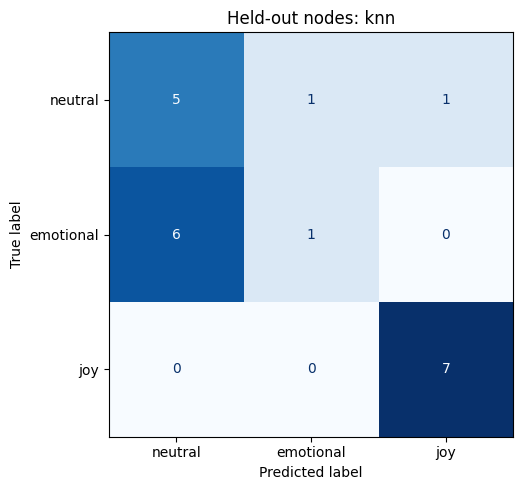

,run_label,node,condition,prediction,correct
0,222_1e,222,emotional,emotional,True
1,222_1n,222,neutral,joy,False
2,222_2e,222,emotional,neutral,False
3,222_2n,222,neutral,neutral,True
4,222_J_1,222,joy,joy,True
5,222_J_2,222,joy,joy,True
6,222_J_3,222,joy,joy,True
7,224_1e,224,emotional,neutral,False
8,224_1n,224,neutral,emotional,False
9,224_2e,224,emotional,neutral,False


Correct: 13 / 21 held-out traces
Small, grouped test set; batch and workload confounding remain possible.


In [6]:
best_model = tuned.best_estimator_
pred = best_model.predict(X_test)
dummy_pred = quick_searches['dummy'].best_estimator_.predict(X_test)
def metrics(truth, prediction):
    return {'accuracy': accuracy_score(truth, prediction),
            'balanced_accuracy': balanced_accuracy_score(truth, prediction),
            'macro_f1': f1_score(truth, prediction, labels=CLASSES, average='macro', zero_division=0)}
test_metrics = pd.DataFrame([metrics(y_test, pred), metrics(y_test, dummy_pred)],
                            index=[best_family, 'dummy'])
display(test_metrics)
report = pd.DataFrame(classification_report(y_test, pred, labels=CLASSES, output_dict=True, zero_division=0)).T
display(report)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASSES, ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Held-out nodes: {best_family}')
plt.tight_layout()
plt.show()
predictions = assignments.iloc[test_idx][['run_label', 'node', 'condition']].copy()
predictions['prediction'] = pred
predictions['correct'] = predictions.condition.eq(predictions.prediction)
display(predictions)
print(f'Correct: {predictions.correct.sum()} / {len(predictions)} held-out traces')
print('Small, grouped test set; batch and workload confounding remain possible.')

## Save reproducible results and fitted pipeline
Exports include all grid scores, exact split assignments, input hashes, software versions, test predictions, and the fitted pipeline. The saved model is trained on the training partition only, preserving the meaning of its held-out evaluation. `feature_columns` records the required input order; raw new feature rows can be passed to `bundle['pipeline'].predict(new_rows[bundle['feature_columns']])` after converting infinities to missing values. Load joblib artifacts only from trusted sources.

In [7]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
leaderboard.to_csv(OUTPUT_DIR / 'classifier_sweep.csv', index=False)
grid_results.to_csv(OUTPUT_DIR / 'grid_search.csv', index=False)
assignments.to_csv(OUTPUT_DIR / 'split_assignments.csv', index=False)
predictions.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)
test_metrics.to_csv(OUTPUT_DIR / 'test_metrics.csv', index_label='classifier')
report.to_csv(OUTPUT_DIR / 'classification_report.csv', index_label='class_or_average')
metadata = {
    'seed': SEED, 'feature_set': FEATURE_SET, 'feature_columns': feature_columns,
    'selected_family': best_family, 'best_params': tuned.best_params_,
    'best_cv_balanced_accuracy': tuned.best_score_,
    'test_metrics': test_metrics.to_dict(orient='index'),
    'train_nodes': sorted(g_train.unique()), 'test_nodes': sorted(g_test.unique()),
    'python': platform.python_version(), 'sklearn': sklearn.__version__,
    'numpy': np.__version__, 'pandas': pd.__version__,
    'input_sha256': {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in paths},
}
(OUTPUT_DIR / 'metadata.json').write_text(json.dumps(metadata, indent=2, default=str) + '\n')
joblib.dump({'pipeline': best_model, 'feature_columns': feature_columns, 'metadata': metadata},
            OUTPUT_DIR / 'best_classifier.joblib')
print('Saved results to:', OUTPUT_DIR)

Saved results to: /Users/rsalvi/Desktop/mccviahat/output/fulltrace_classification_four_throttle
